In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import squarify


# Adding the month and year to df
df = pd.read_csv("Data/allyears.csv", index_col="id")

df['date'] = pd.to_datetime(df['date'])

df['month'] = df['date'].dt.month
df['month'] = df['date'].dt.month_name()
df['year'] = df['date'].dt.year

print(df.head())

         date              client       volunteer                 pantry  \
id                                                                         
0  2024-01-03      Rose Ellington      Lana Price  Gardens (Food Pantry)   
1  2024-01-03        Richard Doty      Lana Price  Gardens (Food Pantry)   
2  2024-01-03       Sydney Berger      Lana Price  Gardens (Food Pantry)   
3  2024-01-03  Christina Robinson      Lana Price  Gardens (Food Pantry)   
4  2024-01-03         Jeff Barney  Robert Cushing  Gardens (Food Pantry)   

      month  year  
id                 
0   January  2024  
1   January  2024  
2   January  2024  
3   January  2024  
4   January  2024  


In [3]:
df_2025 = df[df['year'] == 2025]

client_dict = {} # client_name: list of all dates
client_time = {} # client: (days, times)
# days they used p2p (subtracting last date from first date)
# amount of times they used it 

for client, date in df_2025[["client", "date"]].dropna().itertuples(index=False):
    client_dict.setdefault(client.title(), []).append(date)
    # setting up client_dict


for client, dates in client_dict.items():
    # setting up client_time
    times = len(dates)
    time = (dates[-1] - dates[0]).days
    if time == 0:
        time = 1
    client_time[client] = (time, times)


print(client_time)

{'Hannah Lake': (320, 18), 'Karli Schuffler': (201, 4), 'Zullany Padilla': (14, 2), 'Maria Gallup-Alvarez': (1, 1), 'Shawna Parkinson': (349, 15), 'Marielys Castrillo': (350, 21), 'Phandery Keo': (272, 18), 'Jessie Lavery': (308, 16), 'Danielle Rich': (1, 1), 'Melissa Najera': (1, 1), 'Dilia Gallardo': (14, 2), 'Amanda Spencer': (110, 3), 'Christina Robinson': (354, 20), 'Diana Montelongo': (322, 4), 'Antonio Manzano': (1, 1), 'Richard Garcia': (152, 2), 'Joyce Johnson': (1, 1), 'Fany Morales': (1, 1), 'Leticia Richardson': (1, 1), 'Malissa Vargas-Mendez': (1, 1), 'Martha Leal': (1, 1), 'David Christensen': (271, 12), 'Daniel Quintana': (256, 11), 'Jessamy Benington': (56, 4), 'Roselbia Chilel': (68, 2), 'Barb Montano': (91, 3), 'Bridgette Lopez': (63, 3), 'Rose Champagne': (354, 22), 'Jessica Cornish': (348, 9), 'Wes Wright': (1, 1), 'Ashley Godfrey': (1, 1), 'Mark Duplessis': (68, 3), 'Kellen Chlarson': (1, 1), 'Cassandra Tingey': (175, 8), 'Aloys Manirakiza': (35, 2), 'Liduvina Rami

In [4]:
clients = len(client_time)
num_once = 0
num_five = 0
for dates in client_time.values():
    d = dates[1]
    match d:
        case 1:
            num_once += 1
        case val if val < 5:
            num_five += 1

percent_once = (num_once * 100) / clients
percent_five = (num_five * 100) / clients

print(f"Only once {percent_once}")
print(f"5 or less times {percent_five}")
print(f"More than 5 times {100 - percent_five - percent_once}")

Only once 52.99198025909932
5 or less times 30.043183220234422
More than 5 times 16.964836520666253


In [5]:
# finding average amount of days client use p2p
all_days = 0
clients = len(client_time)

for client, days in client_time.items():
    all_days += days[0]


ave_days = all_days / clients

print(ave_days)

65.8476249228871


In [6]:
# finding max number of days someone used p2p
max_val = 0

for value in client_time.values():
    if value[0] > max_val:
        max_val = value[0]

print(max_val)


361


In [7]:
# finding max number of times someone used p2p

max_times = 0

for value in client_time.values():
    if value[1] > max_times:
        max_times = value[1]


print(max_times)

26


In [8]:
# finding average number of times clients use p2p

times = 0
clients = len(client_dict)

for value in client_time.values():
    times += value[1]

ave_times = times / clients

print(ave_times)

2.985811227637261


In [9]:
# making it all 1 function 

def analyze_p2p(year):
    df = pd.read_csv("Data/allyears.csv", index_col="id")

    df['date'] = pd.to_datetime(df['date'])

    df['month'] = df['date'].dt.month
    df['month'] = df['date'].dt.month_name()
    df['year'] = df['date'].dt.year

    df = df[df['year'] == year]

    client_dict = {} # client_name: list of all dates
    client_time = {} # client: (days, times)
    # days they used p2p (subtracting last date from first date)
    # amount of times they used it 

    for client, date in df[["client", "date"]].dropna().itertuples(index=False):
        client_dict.setdefault(client.title(), []).append(date)
        # setting up client_dict


    for client, dates in client_dict.items():
        # setting up client_time
        times = len(dates)
        time = (dates[-1] - dates[0]).days
        if time == 0:
            time = 1
        client_time[client] = (time, times)


    all_days = 0
    clients = len(client_time)
    max_val = 0
    max_times = 0
    times = 0

    for client, days in client_time.items():
        all_days += days[0] # all days 
        times += value[1] # number of times total

        if days[0] > max_val:
            max_val = days[0] # max num of days
        
        if days[1] > max_times:
            max_times = days[1] # max times


    ave_days = all_days / clients

    ave_times = times / clients

    final_dict = {
        "client_info": client_time,
        "ave_days": ave_days,
        "max_times": max_times,
        "max_days": max_val,
        "ave_times": ave_times
    }
    
    return final_dict


In [10]:
results_2024 = analyze_p2p(2024)
results_2025 = analyze_p2p(2025)


print(f"2024 data:\nAverage days: {results_2024['ave_days']}\
      \nMax days: {results_2024['max_days']}\
      \nAverage times: {results_2024['ave_times']}\
      \nMax times: {results_2024['max_times']}")

print(f"\n2025 data:\nAverage days: {results_2025['ave_days']}\
      \nMax days: {results_2025['max_days']}\
      \nAverage times: {results_2025['ave_times']}\
      \nMax times: {results_2025['max_times']}")

2024 data:
Average days: 53.86031746031746      
Max days: 359      
Average times: 1.0      
Max times: 35

2025 data:
Average days: 65.8476249228871      
Max days: 361      
Average times: 1.0      
Max times: 26


In [11]:
# Maybe get the percentage of people who use it once vs multiple times

In [12]:

def find_percentage(year, display=False):
    db = analyze_p2p(year)["client_info"]
    clients = len(db)
    num_once = 0
    num_five = 0
    for dates in db.values():
        d = dates[1]
        match d:
            case 1:
                num_once += 1
            case val if val < 5:
                num_five += 1

    percent_once = round(((num_once * 100) / clients), 2)
    percent_five = round(((num_five * 100) / clients), 2)
    percent_rest = round((100 - percent_five - percent_once), 2)

    if display:
        print(f"Info for {year}")
        print(f"Only once {percent_once}")
        print(f"5 or less times {percent_five}")
        print(f"More than 5 times {percent_rest}")
    
    return percent_once, percent_five, percent_rest



def find_percentage_fine(year, display=False):
    db = analyze_p2p(year)["client_info"]
    clients = len(db)
    num_once = 0
    num_four = 0
    num_five = 0
    num_ten = 0
    for dates in db.values():
        d = dates[1]
        match d:
            case 1:
                num_once += 1
            case val if val <= 3:
                num_four += 1
            case val if val <= 7:
                num_five += 1
            case val if val <= 10:
                num_ten += 1

    percent_once = round(((num_once * 100) / clients), 2)
    percent_four = round(((num_four * 100) / clients), 2)
    percent_five = round(((num_five * 100) / clients), 2)
    percent_ten = round(((num_ten * 100) / clients), 2)
    percent_rest = round((100 - percent_five - percent_once - percent_four - percent_ten), 2)

    
    return [percent_once, percent_four, percent_five, percent_ten, percent_rest]




In [13]:
once_24, five_24, rest_24 = find_percentage(2024, display=True)
print()
once_25, five_25, rest_25 = find_percentage(2025, display=True)

Info for 2024
Only once 61.27
5 or less times 24.05
More than 5 times 14.68

Info for 2025
Only once 52.99
5 or less times 30.04
More than 5 times 16.97


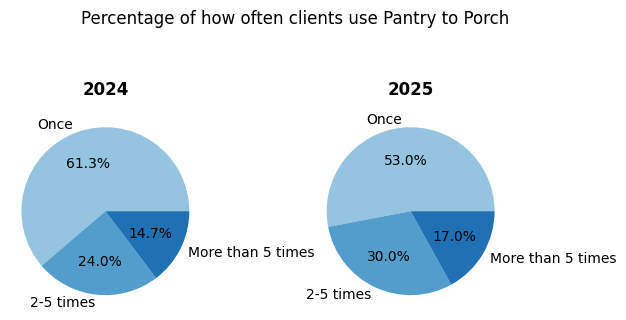

In [38]:
import numpy as np
data_24 = [once_24, five_24, rest_24]
data_25 = [once_25, five_25, rest_25]

labels = ["Once", "2-5 times", "More than 5 times"]
colors = plt.cm.Blues(np.linspace(0.4, 0.75, len(labels)))

fig, axes = plt.subplots(1, 2)

axes[0].pie(data_24, labels=labels, autopct='%1.1f%%', colors=colors, radius=1.1)
axes[0].set_title("2024", fontsize=12, fontweight="bold", pad=15)


axes[1].pie(data_25, labels=labels, autopct='%1.1f%%', colors=colors, radius=1.1)
axes[1].set_title("2025", fontsize=12, fontweight="bold", pad=15)
plt.subplots_adjust(wspace=0.6)
plt.subplots_adjust(top=1.01)

plt.suptitle("Percentage of how often clients use Pantry to Porch", x=0.57)
plt.show()

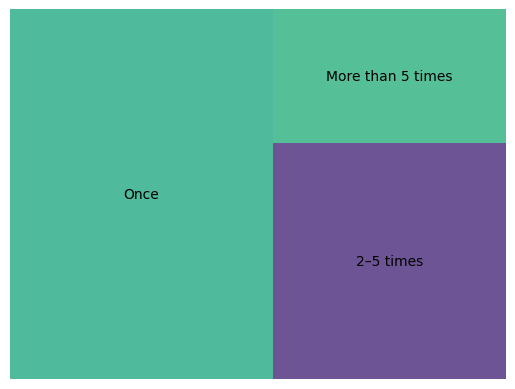

In [15]:

squarify.plot(sizes=data_25, label=labels, alpha=0.8)
plt.axis('off') # Hide axes for a cleaner look
plt.show()

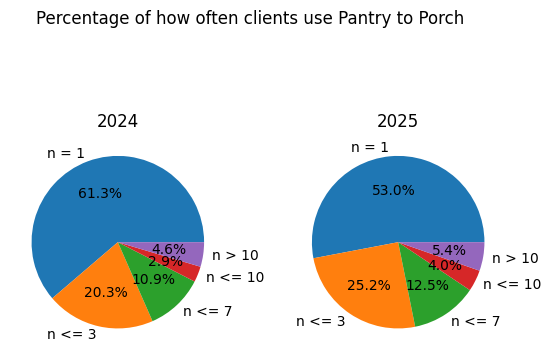

In [16]:
data_24 = find_percentage_fine(2024)
data_25 = find_percentage_fine(2025)

labels = ["n = 1", "n <= 3", "n <= 7", "n <= 10", "n > 10"]

fig, axes = plt.subplots(1, 2)

axes[0].pie(data_24, labels=labels, autopct='%1.1f%%')
axes[0].set_title("2024")

axes[1].pie(data_25, labels=labels, autopct='%1.1f%%')
axes[1].set_title("2025")
plt.subplots_adjust(wspace=0.3)

plt.suptitle("Percentage of how often clients use Pantry to Porch")
plt.show()

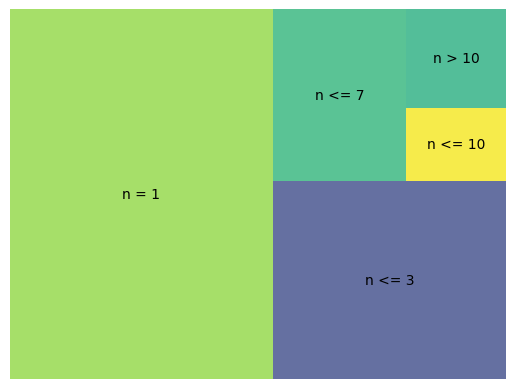

In [17]:


squarify.plot(sizes=data_25, label=labels, alpha=0.8)
plt.axis('off') # Hide axes for a cleaner look
plt.show()